<a href="https://colab.research.google.com/github/richayanamandra/GenAI-Experiments/blob/main/genAI_lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content (1).jpg
Saving style.jpg to style.jpg


In [4]:
image_size = 512

loader = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert('RGB')
    image = loader(image).unsqueeze(0)
    return image.to(device)

content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

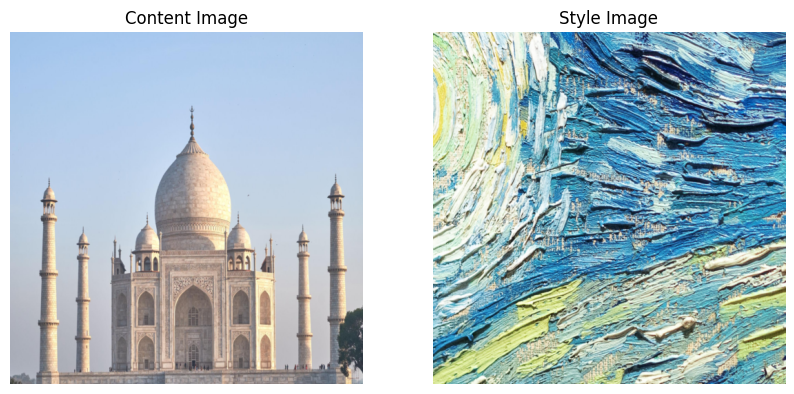

In [5]:
def imshow(tensor, title=None):
    image = tensor.cpu().clone().detach().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
imshow(content_image, "Content Image")

plt.subplot(1,2,2)
imshow(style_image, "Style Image")

In [6]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 106MB/s]


In [7]:
content_layer = 'conv4_2'

style_layers = [
    'conv1_1',
    'conv2_1',
    'conv3_1',
    'conv4_1',
    'conv5_1'
]

In [8]:
def get_features(image, model):

    layers = {
        '0':'conv1_1',
        '5':'conv2_1',
        '10':'conv3_1',
        '19':'conv4_1',
        '21':'conv4_2',
        '28':'conv5_1'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[layers[name]] = x

    return features

In [9]:
def gram_matrix(tensor):

    b, c, h, w = tensor.size()

    tensor = tensor.view(c, h * w)

    gram = torch.mm(tensor, tensor.t())

    return gram

In [10]:
content_features = get_features(content_image, vgg)
style_features = get_features(style_image, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

In [11]:
generated = content_image.clone().requires_grad_(True).to(device)

In [20]:
content_weight = 1e4
style_weight = 1e5

In [21]:
optimizer = optim.Adam([generated], lr=0.001)

In [22]:
steps = 1500

for step in range(steps):

    gen_features = get_features(generated, vgg)

    # Content Loss
    content_loss = torch.mean(
        (gen_features[content_layer] - content_features[content_layer]) ** 2
    )

    # Style Loss
    style_loss = 0

    for layer in style_layers:

        gen_feature = gen_features[layer]
        gen_gram = gram_matrix(gen_feature)

        style_gram = style_grams[layer]

        _, c, h, w = gen_feature.shape

        layer_style_loss = torch.mean((gen_gram - style_gram) ** 2)

        style_loss += layer_style_loss / (c * h * w)

    # Total Loss
    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Total Loss: {total_loss.item()}")

Step 0, Total Loss: 51048.08203125
Step 50, Total Loss: 32841.1484375
Step 100, Total Loss: 30779.5234375
Step 150, Total Loss: 29565.806640625
Step 200, Total Loss: 28679.859375
Step 250, Total Loss: 27982.30859375
Step 300, Total Loss: 27413.203125
Step 350, Total Loss: 26948.6953125
Step 400, Total Loss: 26558.875
Step 450, Total Loss: 26230.8203125
Step 500, Total Loss: 25947.8828125
Step 550, Total Loss: 25703.697265625
Step 600, Total Loss: 25495.95703125
Step 650, Total Loss: 25313.212890625
Step 700, Total Loss: 25135.08984375
Step 750, Total Loss: 24982.22265625
Step 800, Total Loss: 24851.171875
Step 850, Total Loss: 24736.25390625
Step 900, Total Loss: 24623.3203125
Step 950, Total Loss: 24515.703125
Step 1000, Total Loss: 24423.76953125
Step 1050, Total Loss: 24356.619140625
Step 1100, Total Loss: 24262.091796875
Step 1150, Total Loss: 24190.494140625
Step 1200, Total Loss: 24118.75390625
Step 1250, Total Loss: 24048.8359375
Step 1300, Total Loss: 23982.962890625
Step 1350,

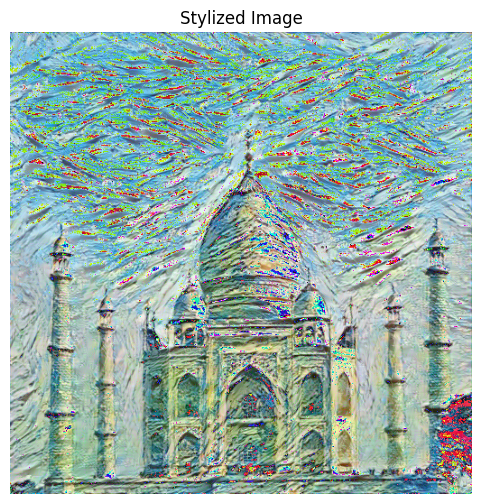

In [23]:
plt.figure(figsize=(6,6))
imshow(generated, "Stylized Image")